In [2]:
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_rows", 100)

path = Path("data")
neighbourhood_path = path.joinpath("neighbourhoods")
ttc_path = path.joinpath("ttc")
housing_path = path.joinpath("housing")

In [3]:
import random
import time
from urllib.request import Request, urlopen

from bs4 import BeautifulSoup


def fetch_sold_url():
    total_pages = 345
    links = pd.DataFrame(columns=["link"])
    curr_link = 0

    for page in range(1, total_pages + 1):
        user_agent = "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:144.0) Gecko/20100101 Firefox/144.0"
        token = ""
        url = (
            "https://www.zolo.ca/index.php?s_r=3"
            if page == 1
            else f"https://www.zolo.ca/index.php/page-{page}?s_r=3"
        )
        headers = {"User-Agent": user_agent, "Cookie": f"token={token}"}

        request = Request(url, None, headers)
        raw = urlopen(request).read()
        soup = BeautifulSoup(raw, "html.parser")
        postings = soup.find_all("a", class_="address text-primary")

        for posting in postings:
            links.loc[curr_link] = str(posting.get("href"))
            curr_link += 1

        time.sleep(random.uniform(1, 4))
    links.to_csv(housing_path.joinpath("house_links.csv"), index=False)

In [4]:
import os

import googlemaps


def normalize_feature(label):
    features = [
        "days_on_market",
        "sold_date",
        "sold_price",
        "age",
        "area",
        "municipality",
        "list_price",
        "bedrooms",
        "bedrooms_plus",
        "bathrooms",
        "kitchens",
        "rooms",
        "central_vac",
        "fireplace",
        "basement",
        "heating",
        "heating_type",
        "heating_fuel",
        "garage",
        "parking_places",
        "parking_total",
        "covered_parking_places",
        "address",
        "lat",
        "lon",
    ]
    feature_map = {
        "type": "house_type",
        "style": "house_style",
        "size (sq ft)": "size",
        "mls®#": "mls",
        "den/family room": "den_or_family_room",
        "air conditioning": "air_conditioning_type",
        "community": "neighbourhood",
    }
    temp_label = label.strip().lower()
    if temp_label in feature_map:
        return feature_map[temp_label]
    temp_label = "_".join(temp_label.split(" "))
    return temp_label if temp_label in features else None


def fetch_sold_details(houses, links):
    skipped = []

    for i in range(links.shape[0]):
        try:
            if i > 0 and i % 250 == 0:
                time.sleep(random.uniform(60, 120))

            url = links.at[i, "link"]
            user_agent = "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:144.0) Gecko/20100101 Firefox/144.0"
            token = ""
            headers = {"User-Agent": user_agent, "Cookie": f"token={token}"}

            request = Request(url, None, headers)
            raw = urlopen(request).read()
            soup = BeautifulSoup(raw, "html.parser")

            # Look for all features
            for label_dt in soup.find_all("dt", class_="column-label"):
                label_text = label_dt.text.strip().lower()

                feature_name = normalize_feature(label_text)
                if feature_name is None:
                    continue

                span = label_dt.find_next_sibling("dd").find("span")
                if not span:
                    continue
                feature_value = span.text.strip().lower()
                houses.at[i, feature_name] = feature_value

            for label_div in soup.find_all("div", class_="column-label"):
                label_text = label_div.text.strip().lower()

                feature_name = normalize_feature(label_text)
                if feature_name is None:
                    continue

                span = label_div.find_next_sibling("div").find("span")
                if not span:
                    continue
                feature_value = span.text.strip().lower()

                if feature_name == "heating":
                    if (
                        pd.isna(houses.at[i, "heating"])
                        or houses.at[i, "heating"] == ""
                    ):
                        houses.at[i, "heating"] = feature_value
                    else:
                        houses.at[i, "heating"] += f", {feature_value}"
                else:
                    houses.at[i, feature_name] = feature_value

            # Special features not in the description
            address = soup.find("h1", class_="address").text.strip().lower()
            houses.at[i, "address"] = address

            print("Progress:", i)
            print(len(houses))
            time.sleep(random.uniform(1, 3))
        except Exception as e:
            print(f"Skipped {i}: {e}")
            skipped.append(i)
            continue

    print("Total skipped:", len(skipped))


def geocode_loc(houses):
    key = os.getenv("GOOGLE_API_KEY")
    gmaps = googlemaps.Client(key=key)

    for i, row in houses.iterrows():
        if not (pd.isna(row["lat"]) or pd.isna(row["lon"])):
            continue

        address = f'{row["address"]}, {row["neighbourhood"]}'
        geocode_result = gmaps.geocode(address)

        if geocode_result:
            loc = geocode_result[0]["geometry"]["location"]
            houses.at[i, "lat"] = loc["lat"]
            houses.at[i, "lon"] = loc["lng"]

        time.sleep(0.2)

In [5]:
def split_heating(houses):
    split = houses["heating"].str.split(", ", n=1, expand=True)
    houses["heating_fuel"] = split[0]
    houses["heating_type"] = split[1]

    houses.drop(columns=["heating"], inplace=True)

# Neighbourhood Mapping


In [6]:
# Populating the table with housing data
links = pd.read_csv(housing_path.joinpath("house_links.csv"))

if (p := housing_path.joinpath("housing.csv")).exists():
    houses = pd.read_csv(p)
else:
    houses = pd.DataFrame(
        columns=[
            "days_on_market",
            "sold_date",
            "sold_price",
            "age",
            "house_type",
            "house_style",
            "size",
            "area",
            "municipality",
            "neighbourhood",
            "list_price",
            "bedrooms",
            "bedrooms_plus",
            "bathrooms",
            "kitchens",
            "rooms",
            "den_or_family_room",
            "central_vac",
            "air_conditioning_type",
            "fireplace",
            "basement",
            "heating",
            "heating_type",
            "heating_fuel",
            "garage",
            "parking_places",
            "parking_total",
            "covered_parking_places",
            "mls",
            "address",
            "lat",
            "lon",
        ]
    )

In [7]:
profile_path = neighbourhood_path.joinpath("neighbourhood-profiles-2021-158-model.xlsx")

profile = pd.read_excel(profile_path)
profile = profile.set_index(profile.columns[0]).T
profile.index = profile.index.str.strip()

profile_to_house_map = {
    "Cabbagetown-South St. James Town": "Cabbagetown-South St.James Town",
    "Danforth-East York": "Danforth East York",
    "East End Danforth": "East End-Danforth",
    "North St. James Town": "North St.James Town",
    "O`Connor Parkview": "O'Connor-Parkview",
    "Taylor Massey": "Taylor-Massey",
    "Yonge-St. Clair": "Yonge-St.Clair",
}

profile.index = profile.index.to_series().replace(profile_to_house_map)

In [8]:
import re

cols = []
for idx, col in enumerate(profile.columns):
    match = re.match("\\s+", col)
    indent = 0 if match is None else len(match.group())
    cols.append((idx, indent // 2, col[indent:]))

unique_names = []
current_path = {}

for idx, level, name in cols:
    if level == 0:
        current_path = {}
    current_path[level] = name
    full_name = " > ".join([current_path[i] for i in range(level + 1)])
    unique_names.append(full_name)

profile = profile.convert_dtypes()
profile.columns = unique_names

In [9]:
neighbourhoods = gpd.read_file(neighbourhood_path.joinpath("neighbourhoods.geojson"))

neighbourhoods = neighbourhoods[["AREA_NAME", "AREA_SHORT_CODE", "geometry"]]
neighbourhoods["AREA_NAME"] = neighbourhoods["AREA_NAME"].str.strip()
neighbourhoods["AREA_SHORT_CODE"] = neighbourhoods["AREA_SHORT_CODE"].astype(int)
t_all_data = neighbourhoods.merge(
    profile, left_on="AREA_NAME", right_index=True, how="left"
).reset_index(drop=True)

t_all_data = t_all_data.rename(columns={"AREA_NAME": "neighbourhood"})

# Housing Statistics


- Neighbourhood Income (maybe household)
- Age (mean, median)
- Housings Prices projected on Neighbourhood Income
- Demographic (Language, Ethnicity)
- Population (Change, Total)
- Education
- Commuting (public transit access, commute time breakdown)
- Transit
- Listing


In [10]:
price_floor = houses["sold_price"].quantile(0.05)
houses = houses[houses["sold_price"] >= price_floor]

house_type_mapping = {
    "condo apartment": "Condo Apt",
    "co-op apartment": "Co-Op Apt",
    "co-ownership apartment": "Co-Ownership Apt",
    "detached": "Detached",
    "semi-detached": "Semi-Detached",
    "condo townhouse": "Condo Townhouse",
    "att/row/townhouse": "Att/Row/Townhouse",
    "common element condo": "Comm Element Condo",
    "link": "Link",
    "duplex": "Multiplex",
    "triplex": "Multiplex",
    "fourplex": "Multiplex",
    "multiplex": "Multiplex",
}

houses.loc[:, "final_type"] = houses["house_type"].map(house_type_mapping)
houses = houses.dropna(subset=["final_type"])
houses = houses.drop(columns=["house_type"])
houses = houses.rename(columns={"final_type": "house_type"})

In [11]:
# Moving neighbourhoods from 140 model to 158 (2021 onwards)
houses = gpd.GeoDataFrame(
    houses, geometry=gpd.points_from_xy(houses.lon, houses.lat), crs=neighbourhoods.crs
)

# Join houses (140-neighbourhood names) with 158-model neighbourhood names
houses = gpd.sjoin(
    houses,
    neighbourhoods[["AREA_NAME", "AREA_SHORT_CODE", "geometry"]],
    how="left",
    predicate="within",
)

houses = houses.drop(columns=["municipality", "neighbourhood", "index_right"])
houses = houses.rename(columns={"AREA_NAME": "neighbourhood"})
houses.head(2)

,days_on_market,sold_date,sold_price,age,house_style,size,area,list_price,bedrooms,bedrooms_plus,...,parking_total,covered_parking_places,mls,address,lat,lon,house_type,geometry,neighbourhood,AREA_SHORT_CODE
0,21,2025-11-12,740000.0,no data,3-storey,1100-1500,toronto,699900,3.0,1.0,...,2.0,1.0,w12476861,127 torbarrie road,43.726329,-79.523197,Att/Row/Townhouse,POINT (-79.5232 43.72633),Oakdale-Beverley Heights,154
1,9,2025-11-12,980000.0,no data,2-storey,700-1100,toronto,989000,2.0,NaN,...,0.0,0.0,e12501558,99 newmarket avenue,43.689673,-79.304911,Semi-Detached,POINT (-79.30491 43.68967),East End-Danforth,62


In [244]:
import json

import bokeh
import xyzservices.providers as xyz
from bokeh.embed import json_item
from bokeh.io import output_file, output_notebook, show
from bokeh.layouts import column
from bokeh.models import (
    ColorBar,
    ColumnDataSource,
    CustomJS,
    DataRange1d,
    GeoJSONDataSource,
    HoverTool,
    Label,
    LinearColorMapper,
    NumeralTickFormatter,
    Span,
    TapTool,
)
from bokeh.palettes import BuPu
from bokeh.plotting import figure

In [236]:
columns = {
    "med_income": "Total - Income statistics for private households - 25% sample data > Median total income of household in 2020 ($)",
    "avg_age": "Average age of the population",
    "avg_household_size": "Average household size",
    "employment_rate": "Employment rate",
    "unemployment_rate": "Unemployment rate",
}

required_cols = ["geometry", "neighbourhood"] + list(columns.values())


def add_layer(
    figure: bokeh.plotting.figure,
    geosource: GeoJSONDataSource,
    name: str,
    cb_formatter=None,
    palette: bokeh.palettes.Palette = BuPu[9][::-1],
    hover_formatter: str = None,
    display_name: str = None,
    suffix: str = "",
):
    data_col = columns[name]

    color_mapper = LinearColorMapper(
        palette=palette,
        low=t_all_data[data_col].min(),
        high=t_all_data[data_col].max(),
    )

    layer = figure.patches(
        "xs",
        "ys",
        source=geosource,
        line_color="black",
        line_width=0.5,
        fill_color={"field": data_col, "transform": color_mapper},
        fill_alpha=0.5,
        name=f"{name}_layer",
        visible=False,
    )

    hover_callback = CustomJS(
        args=dict(source=geosource, col_map=columns),
        code="""
        export default (args, obj, data, context) => {
            // obj is the HoverTool itself. 
            // If the tool is not visible, DON'T send any events.
            if (!obj.visible) return;

            const indices = data.index.indices;
            if (indices.length > 0) {
                const i = indices[0];
                const active_id = (args.source.tags && args.source.tags.length > 0) 
                                ? args.source.tags[0] 
                                : null;
                const data_field = args.col_map[active_id];

                if (data_field && args.source.data[data_field]) {
                    const val = args.source.data[data_field][i];
                    window.dispatchEvent(new CustomEvent("bokeh_hover", {
                        detail: { value: val }
                    }));
                }
            } else {
                window.dispatchEvent(new CustomEvent("bokeh_hover", {
                    detail: { value: null }
                }));
            }
        }
        """,
    )

    hover = HoverTool(
        renderers=[layer],
        tooltips=[
            ("Neighbourhood", "@neighbourhood"),
            (f"{display_name}", f"@{{{data_col}}}{{{hover_formatter}}}{suffix}"),
        ],
        name=f"{name}_hover",
        visible=False,
        callback=hover_callback,
        mode="mouse",
    )
    figure.add_tools(hover)

    color_bar = layer.construct_color_bar(
        padding=1,
        width=600,
        location=(0, 0),
        formatter=cb_formatter if cb_formatter else "auto",
        name=f"{name}_cb",
        visible=False,
    )

    figure.add_layout(color_bar, "below")

    layer.selection_glyph = layer.glyph.clone()
    layer.selection_glyph.line_color = "black"
    layer.selection_glyph.line_width = 3
    layer.selection_glyph.fill_alpha = 1
    layer.nonselection_glyph = layer.glyph.clone()

    return layer, hover

In [237]:
# Convert neighbourhood geopandas to json
geosource = GeoJSONDataSource(
    geojson=t_all_data[required_cols].to_crs(epsg=3857).to_json(), name="main_geosource"
)

toronto_x_range = (-8886962, -8785511)
toronto_y_range = (5397395, 5446533)

p = figure(
    x_range=DataRange1d(bounds=toronto_x_range),
    y_range=DataRange1d(bounds=toronto_y_range),
    match_aspect=True,
    aspect_scale=1,
    x_axis_type="mercator",
    y_axis_type="mercator",
    tools="pan,wheel_zoom,reset,save",
    sizing_mode="stretch_both",
)
p.xgrid.grid_line_color = None
p.ygrid.grid_line_color = None
p.axis.visible = False

# Prevent zooming out too far
p.x_range.max_interval = 750000
p.y_range.max_interval = 750000

# Prevent zooming in too deep
p.x_range.min_interval = 1000
p.y_range.min_interval = 1000
p.add_tile(xyz.CartoDB.Positron)

# Base neighbourhood renderer
base_layer = p.patches(
    "xs",
    "ys",
    source=geosource,
    line_color="black",
    line_width=0.5,
    fill_alpha=0,
    # Highlighting effects:
    hover_fill_alpha=0.9,
    hover_fill_color="#faa246",
    hover_line_color="black",
    hover_line_width=0.5,
    name="base_layer",
    visible=True,
)

base_hover = HoverTool(
    renderers=[base_layer],  # Add all data layers here
    tooltips=[("Neighbourhood", "@neighbourhood")],
    name="base_hover",
    visible=True,
)
p.add_tools(base_hover)

# Median income renderer
income_layer = add_layer(
    figure=p,
    geosource=geosource,
    name="med_income",
    cb_formatter=NumeralTickFormatter(format="$0a"),
    hover_formatter="$0,0",
    display_name="Median Income",
)

# Average age renderer
age_layer = add_layer(
    figure=p,
    geosource=geosource,
    name="avg_age",
    hover_formatter="0.0",
    display_name="Average Age",
)

# Average household size renderer
household_size_layer = add_layer(
    figure=p,
    geosource=geosource,
    name="avg_household_size",
    hover_formatter="0.0",
    display_name="Average Household Size",
)

# Employment rate renderer
emp_layer = add_layer(
    figure=p,
    geosource=geosource,
    name="employment_rate",
    hover_formatter="0.0",
    suffix="%",
    display_name="Employment Rate",
)

# Unemployment rate renderer
unemp_layer = add_layer(
    figure=p,
    geosource=geosource,
    name="unemployment_rate",
    hover_formatter="0.0",
    suffix="%",
    display_name="Unemployment Rate",
)

# Shaded alpha base on zoom level
zoom_callback = CustomJS(
    args=dict(
        targets=[
            income_layer,
            age_layer,
            household_size_layer,
            emp_layer,
            unemp_layer,
        ]
    ),
    code="""
    export default (args, obj, data, context) => {
        if (!obj || !args.targets) return;
        
        const span = obj.end - obj.start;
        let newAlpha = 0.1 + (span / 60000);
        if (newAlpha > 0.5) newAlpha = 0.5;
        if (newAlpha < 0.2) newAlpha = 0.1;
        
        args.targets.forEach(target => {
            if (target && target.glyph) {
                target.glyph.fill_alpha.value = newAlpha;
            }
        })
    }
    """,
)

# Attach to the X-Range (or Y-Range)
p.x_range.js_on_change("start", zoom_callback)
p.x_range.js_on_change("end", zoom_callback)

geosource.selected.js_on_change(
    "indices",
    CustomJS(
        args=dict(source=geosource),
        code="""
        export default (args, obj, data, context) => {
            const indices = args.source.selected.indices;
            if (indices.length > 5) {
                indices.shift();
                args.source.selected.indices = indices;
            }
            
            const names = indices.map(i => args.source.data["neighbourhood"][i]);
            const event = new CustomEvent("bokeh_select", {
                detail: {
                    indices: indices,
                    names: names,
                }
            });
            window.dispatchEvent(event);
        }
        """,
    ),
)

p.add_tools(TapTool())

item_text = json.dumps(json_item(p, "bokeh-map-container"))
with open(
    os.path.normpath(
        os.path.join(
            os.getcwd(), os.pardir, "Housing Project App", "public", "map_config.json"
        )
    ),
    "w",
) as f:
    f.write(item_text)

# Display figure in Jupyter
# output_notebook()
# show(p)

In [ ]:
hist_data = {}

hist_data["base_counts"] = [0] * 20
hist_data["base_left"] = list(range(20))
hist_data["base_right"] = list(range(1, 21))

for display, col in columns.items():
    measured = t_all_data[col]
    counts, edges = np.histogram(measured, bins=20)

    hist_data[f"{display}_counts"] = counts.tolist()
    hist_data[f"{display}_left"] = edges[:-1].tolist()
    hist_data[f"{display}_right"] = edges[1:].tolist()


initial_col = "base"
active_source = ColumnDataSource(
    data={
        "top": hist_data[f"{initial_col}_counts"],
        "left": hist_data[f"{initial_col}_left"],
        "right": hist_data[f"{initial_col}_right"],
    },
    name="active_source",
)

# Create the Plot
hist_p = figure(
    height=200,
    sizing_mode="stretch_width",
    toolbar_location=None,
    background_fill_color=None,
    border_fill_color=None,
    name="dynamic_hist",
)

hist_p.quad(
    top="top",
    bottom=0,
    left="left",
    right="right",
    source=active_source,
    fill_color="#2b8cbe",
    line_color="white",
    fill_alpha=0.8,
)

hover_span = Span(
    location=0,
    dimension="height",
    line_color="#e74c3c",
    line_width=1,
    visible=False,
    name="hover_indicator",
)
hist_p.add_layout(hover_span)

# Create the label that will sit next to the red line
hover_label = Label(
    x=0,
    y=0,
    x_units="data",
    y_units="screen",
    text="",
    text_font_size="8pt",
    text_font_style="bold",
    text_align="center",
    background_fill_color="white",
    background_fill_alpha=0.7,
    border_line_color=None,
    visible=False,
    name="hover_label_text",
)

hist_p.add_layout(hover_label)

hist_p.yaxis.visible = False
hist_p.xgrid.grid_line_color = None
hist_p.ygrid.grid_line_color = None

update_hist_callback = CustomJS(
    args=dict(source=active_source, all_data=hist_data),
    code="""
    export default(args, obj, data, context) => {
        const col = (args.source.tags && args.source.tags.length > 0) ? args.source.tags[0] : "base";
        
        if (args.all_data[`${col}_counts`]) {
            args.source.data["top"] = args.all_data[`${col}_counts`];
            args.source.data["left"] = args.all_data[`${col}_left`];
            args.source.data["right"] = args.all_data[`${col}_right`];
            args.source.change.emit();
        }
    }
    """,
)

active_source.js_on_change("tags", update_hist_callback)

item_text = json.dumps(json_item(hist_p, "bokeh-hist-container"))
with open(
    os.path.normpath(
        os.path.join(
            os.getcwd(), os.pardir, "Housing Project App", "public", "hist_config.json"
        )
    ),
    "w",
) as f:
    f.write(item_text)

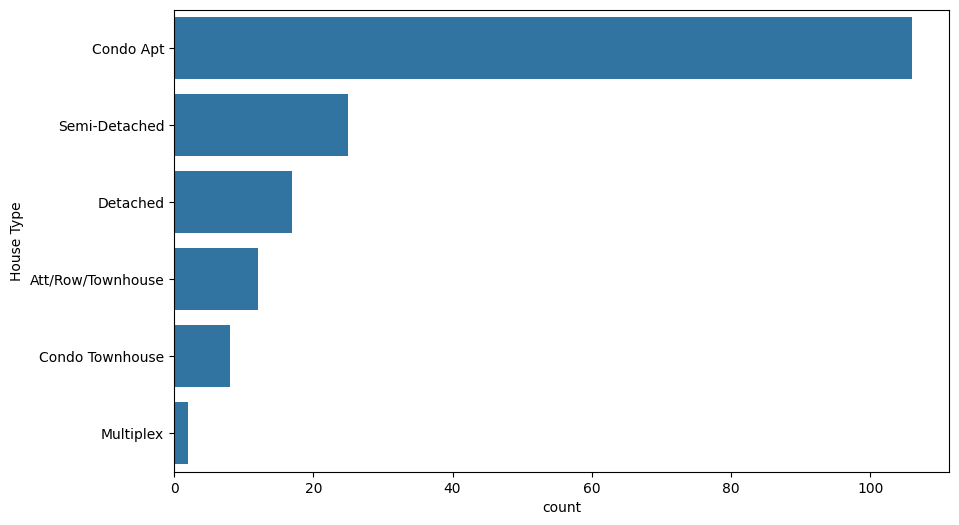

In [18]:
annex = houses[houses["neighbourhood"] == "Annex"]

fig = plt.figure(figsize=(10, 6))
ax = plt.gca()

sns.barplot(annex["house_type"].value_counts(), orient="h")

ax.set_ylabel("House Type")
plt.show()

# Transit


In [19]:
route_type = {
    "tram": 0,
    "streetcar": 0,
    "light_rail": 0,
    "subway": 1,
    "metro": 1,
    "rail": 2,
    "bus": 3,
    "ferry": 4,
    "cable_tram": 5,
    "aerial_lift": 6,
    "furnicular": 7,
    "trolleybus": 11,
    "monorail": 12,
}

dtype_ids = {"route_id": str, "trip_id": str, "stop_id": str}


def read_gtfs(file_name, dtype=None):
    if dtype is not None:
        return pd.read_csv(ttc_path.joinpath(file_name), dtype=dtype)
    return pd.read_csv(ttc_path.joinpath(file_name))

In [20]:
stops = read_gtfs("stops.txt", dtype=dtype_ids)
stops = stops[stops["stop_code"].str.isdigit()]
routes = read_gtfs("routes.txt", dtype=dtype_ids)
trips = read_gtfs("trips.txt", dtype=dtype_ids)
stop_times = read_gtfs("stop_times.txt", dtype=dtype_ids)
shapes = read_gtfs("shapes.txt")


subway_routes = routes[routes["route_type"] == route_type["subway"]]
rail_routes = routes[routes["route_type"] == route_type["rail"]]
bus_routes = routes[routes["route_type"] == route_type["bus"]]

subway_trips = trips[trips["route_id"].isin(subway_routes["route_id"])]
rail_trips = trips[trips["route_id"].isin(rail_routes["route_id"])]
bus_trips = trips[trips["route_id"].isin(bus_routes["route_id"])]

subway_stop_times = stop_times[stop_times["trip_id"].isin(subway_trips["trip_id"])]
rail_stop_times = stop_times[stop_times["trip_id"].isin(rail_trips["trip_id"])]
bus_stop_times = stop_times[stop_times["trip_id"].isin(bus_trips["trip_id"])]

subway_trips_shapes = (
    subway_trips[["route_id", "trip_id", "shape_id"]]
    .drop_duplicates("shape_id")
    .merge(subway_routes[["route_id", "route_color"]], on="route_id", how="left")
)


subway_stops = None

if not ttc_path.joinpath("subway_stops.csv").exists():
    subway_stops = (
        stops[stops["stop_id"].isin(subway_stop_times["stop_id"])]
        .drop_duplicates("stop_id")
        .assign(
            stop_name_clean=lambda df: df["stop_name"]
            .str.split(" - ", n=1)
            .str[0]
            .str.strip()
        )
        .drop_duplicates(subset=["stop_name_clean"])
    )
    subway_stops.to_csv(ttc_path.joinpath("subway_stops.csv"), index=False)
else:
    subway_stops = read_gtfs("subway_stops.csv", dtype=dtype_ids)

rail_stops = stops[stops["stop_id"].isin(rail_stop_times["stop_id"])].drop_duplicates(
    "stop_id"
)
bus_stops = stops[stops["stop_id"].isin(bus_stop_times["stop_id"])].drop_duplicates(
    "stop_id"
)

In [21]:
def get_transit_shape(trips_shapes, shape_df):
    used_shapes_id = trips_shapes["shape_id"].unique()
    used_shapes = shape_df[shape_df["shape_id"].isin(used_shapes_id)]
    rows = []

    for route_id in trips_shapes["route_id"].unique():
        line_shapes = trips_shapes[trips_shapes["route_id"] == route_id]
        shape_counts = (
            used_shapes[used_shapes["shape_id"].isin(line_shapes["shape_id"])]
            .groupby("shape_id")["shape_pt_sequence"]
            .count()
        )
        full_line_shape_id = shape_counts.idxmax()
        line_shape_pts = used_shapes[
            used_shapes["shape_id"] == full_line_shape_id
        ].sort_values("shape_pt_sequence")
        line_geom = LineString(line_shape_pts[["shape_pt_lon", "shape_pt_lat"]].values)
        route_color = f"#{line_shapes['route_color'].iloc[0]}"

        rows.append(
            {
                "route_id": route_id,
                "shape_id": full_line_shape_id,
                "geometry": line_geom,
                "route_color": route_color,
            }
        )
    return gpd.GeoDataFrame(rows, crs="EPSG:4326")